In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [81]:
cancer = load_breast_cancer()
feature_list=list(cancer.feature_names)

df=pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['tipo de cancer']=cancer.target
sub_df=df.iloc[:,2:4].copy()
sub_df["tipo de cancer"]=cancer.target
# mean perimeter - mean area - tipo de cancer 
name_list =[]
for i in range(len(df)):
    tipo = 'maligno'
    if sub_df.iloc[i,2] == 1:
        tipo ='benigno'
    name_list.append(tipo)
sub_df.head()

,mean perimeter,mean area,tipo de cancer
0,122.80,1001.0,0
1,132.90,1326.0,0
2,130.00,1203.0,0
3,77.58,386.1,0
4,135.10,1297.0,0


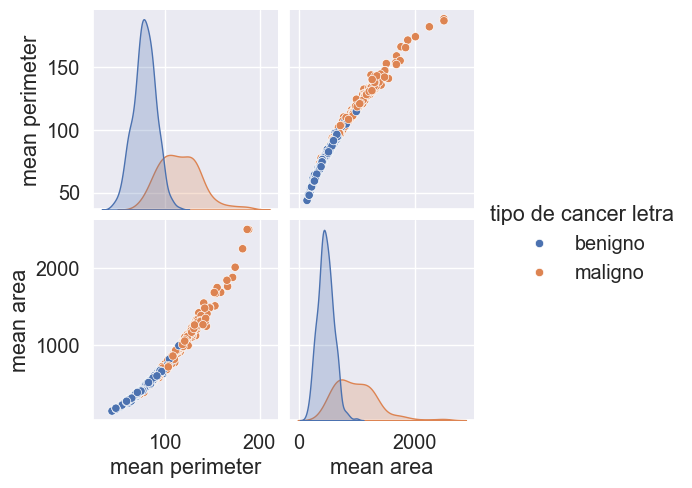

In [82]:
sub_df["tipo de cancer letra"]=name_list
sns.set(font_scale=1.3)
sns.pairplot(sub_df.drop(columns='tipo de cancer'), hue="tipo de cancer letra", 
             hue_order=['benigno','maligno'])
plt.show()

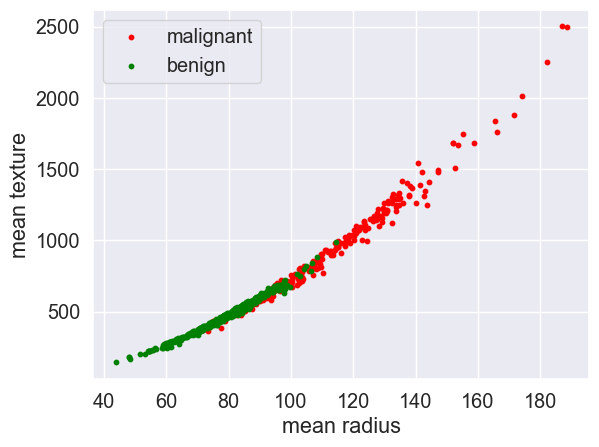

In [83]:
X=sub_df.iloc[:,:2].values
y=sub_df.iloc[:,-2].values
kernel_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='poly', degree=8, coef0=1.5))
])


for i, j in enumerate(np.unique(y)):
    plt.scatter(X[y == j, 0], X[y== j, 1], s=10,
                color = ListedColormap(('red', 'green'))(i), 
                label = cancer.target_names[j])

plt.legend()
plt.xlabel(feature_list[0])
plt.ylabel(feature_list[1])
plt.show()

################# Clasificación #####
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, 
                                                    random_state=0)

### Uso de Pipeline con el método de Kernel ####

# kernel_svm = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm', SVC(kernel='sigmoid'))
# ])

kernel_svm.fit(X_train, y_train)
score = kernel_svm.score(X_test, y_test)

X_set, y_set = X_test, y_test


In [84]:
grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto', 0.1, 1]
}
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(random_state=42))
])
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_weighted': make_scorer(precision_score, average='weighted'),
    'recall_weighted': make_scorer(recall_score, average='weighted'),
    'f1_weighted': make_scorer(f1_score, average='weighted')
}  

            
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid,
    cv=10,
    scoring=scoring,
    n_jobs=-1, 
    verbose=0,
    refit='f1_weighted'
)

grid_search.fit(X_train, y_train)
y_pred_test = grid_search.predict(X_test)
val_accuracy = accuracy_score(y_test, y_pred_test)

for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"Mejor score (CV): {grid_search.best_score_:.4f}")
print(f"Test: {val_accuracy:.4f}")
print()

   classifier__C: 10
   classifier__gamma: scale
   classifier__kernel: linear
Mejor score (CV): 0.8903
Test: 0.8671



In [85]:
# Grid más pequeño y rápido
poly_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 0.1, 1],
    'classifier__degree': [2, 3, 4, 5, 6],  
    'classifier__coef0': [0.0, 1.0, 1.5]  
}

poly_search = GridSearchCV(
    estimator=pipeline,
    param_grid=poly_grid,
    cv=3,  # Solo 3 folds
    scoring='f1_weighted',  
    n_jobs=-1,
    verbose=0,
    refit=True
)

poly_search.fit(X_train, y_train)
y_pred_test_poly = poly_search.predict(X_test)
val_accuracy_poly = accuracy_score(y_test, y_pred_test)

for param, value in poly_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"Mejor score (CV): {grid_search.best_score_:.4f}")
print(f"Test: {val_accuracy_poly:.4f}")
print()

   classifier__C: 0.1
   classifier__coef0: 0.0
   classifier__degree: 2
   classifier__gamma: 1
Mejor score (CV): 0.8903
Test: 0.8671



In [86]:
best_estimatior = poly_search if val_accuracy_poly > val_accuracy else grid_search
best_estimatior = poly_search

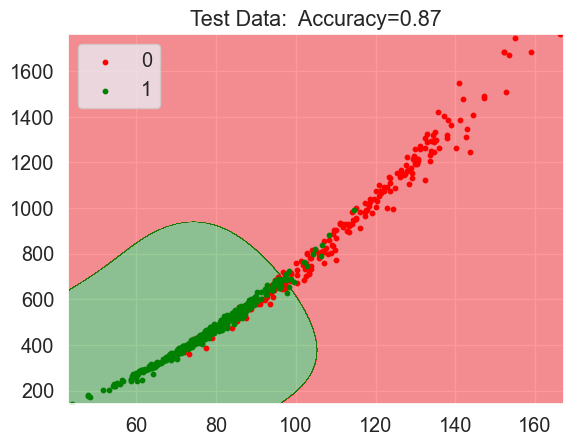

In [87]:
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, 
                               step = 0.1),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, 
                               step = 0.1))


plt.contourf(X1, X2, best_estimatior.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.4, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y)):
    plt.scatter(X[y == j, 0], X[y== j, 1], s=10,
                color = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Test Data:  Accuracy='+str(np.round(score,2)))
plt.legend()
plt.show()